In [1]:
import pandas as pd
import numpy as np

In [2]:
# ## Element of Structure Data
# *Nummerical
#     Continous
#     Discrete - Cannot be divided
# *Catogorical
#     Binary
#     Ordinary - In sequence/order matters

In [3]:
# Rectangular Data
# This refer to matrix of records with column denoting variable and row denoting records

In [4]:
# Data frame other than contains Rectangular data including matrix

In [5]:
# Non-rectangular DataSet
# #Timeseries data measure successive measurement of same variable (non-rectangular because pivoting of data)
# Object Representation : Focuses on an object anf its spatial cordiantes.
# Filed Representation : Focuses on small units of space and thevalue of a relevant metric like pixel brightness.

In [6]:
df_athelet = pd.read_excel("../Data/Athletes.xlsx")

In [7]:
df_athelet

,Name,NOC,Discipline
0,AALERUD Katrine,Norway,Cycling Road
1,ABAD Nestor,Spain,Artistic Gymnastics
2,ABAGNALE Giovanni,Italy,Rowing
3,ABALDE Alberto,Spain,Basketball
4,ABALDE Tamara,Spain,Basketball
...,...,...,...
11080,ZWICKER Martin Detlef,Germany,Hockey
11081,ZWOLINSKA Klaudia,Poland,Canoe Slalom
11082,ZYKOVA Yulia,ROC,Shooting
11083,ZYUZINA Ekaterina,ROC,Sailing


In [8]:
df_athelet = pd.read_excel("../Data/Athletes.xlsx")

In [9]:
df_medal = pd.read_excel("../Data/medals.xlsx")

/opt/anaconda3/envs/MLTest/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [10]:
df_medal

,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1
1,2,People's Republic of China,38,32,18,88,2
2,3,Japan,27,14,17,58,5
3,4,Great Britain,22,21,22,65,4
4,5,ROC,20,28,23,71,3
...,...,...,...,...,...,...,...
88,86,Ghana,0,0,1,1,77
89,86,Grenada,0,0,1,1,77
90,86,Kuwait,0,0,1,1,77
91,86,Republic of Moldova,0,0,1,1,77


In [11]:
df_medal['Total'].mean()

11.612903225806452

In [12]:
df_medal['Gold'].mean()

3.6559139784946235

In [13]:
##Weighted means
np.average(df_medal['Gold'],weights=df_medal['Total'] )

14.743518518518519

In [14]:
#trim mean
from scipy.stats import trim_mean
trim_mean(df_medal['Gold'],0.1)

1.96

In [15]:
#list(df_medal['Gold'])

In [16]:
df_medal['Gold'].median()

1.0

In [17]:
##weighted mean
def weighed_median(df,median_col,weight_col):
    df_sorted = df.sort_values(median_col)
    cumsum = df_sorted[weight_col].cumsum()
    cutoff = df_sorted[weight_col].sum()/2.
    return df_sorted[cumsum>=cutoff][median_col].iloc[0]

In [18]:
weighed_median(df_medal,'Total','Gold')

40

In [19]:
#percentile
#75/100 * n = 0.75n
q3= np.percentile(df_medal['Total'],75)

In [20]:
q3

11.0

In [21]:
df_medal.describe()

,Rank,Gold,Silver,Bronze,Total,Rank by Total
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,46.333333,3.655914,3.634409,4.322581,11.612903,43.494624
std,26.219116,7.022471,6.626339,6.210372,19.091332,24.171769
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,24.000000,0.000000,0.000000,1.000000,2.000000,23.000000
50%,46.000000,1.000000,1.000000,2.000000,4.000000,47.000000
75%,70.000000,3.000000,4.000000,5.000000,11.000000,66.000000
max,86.000000,39.000000,41.000000,33.000000,113.000000,77.000000


In [22]:
#Variablity is at heart of statistics and where a lot of information on a dataset can be gleaned.
#Deviation : difference of opbserved value and the estimate of location also called error & residual.
#Variance (n-1) : Square of deviation .from mean

In [23]:
#Variance and Standard deviation
from statistics import variance ,stdev

variance(df_medal['Total'])

364.4789621318373

In [24]:
df_medal['Total'].var()

364.4789621318374

In [25]:
df_medal['Total'].std()

19.091332120411018

In [26]:
stdev(df_medal['Total'])

19.091332120411014

In [27]:
# Mean absolute deviation
# Mean of absolute value of deviations from means 
# from numpy import mean,absolute
# mean(absolute(X-mean(X)))

In [28]:
from numpy import mean,absolute
mean(absolute(df_medal['Gold']-mean(df_medal['Gold'])))


4.0048560527228565

In [29]:
#Median of the absolute devaition
#Median of the absolute values of the devaiteion from the media

In [30]:
from numpy import median,absolute
median(absolute(df_medal['Gold']-median(df_medal['Gold'])))

1.0

In [31]:
# Interquantile range
q3,q1= np.percentile(df_medal['Gold'],[75,25])

In [32]:
iqr=q3-q1

In [33]:
iqr

3.0

In [34]:
#Boxplot & Histogram for frequuency - Data Distribution

In [35]:
import pandas as pd

# Example Series
data = pd.Series([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# Calculate the quantiles at specified levels
quantiles = data.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

print(quantiles)


0.05    14.5
0.25    32.5
0.50    55.0
0.75    77.5
0.95    95.5
dtype: float64


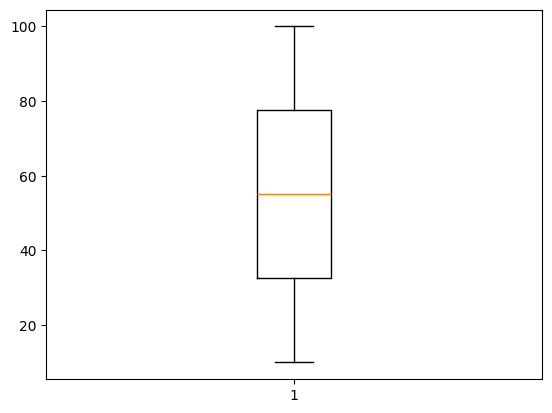

In [36]:
import matplotlib.pyplot as plt

# Plot the boxplot
plt.boxplot(data)
plt.show()


<Axes: >

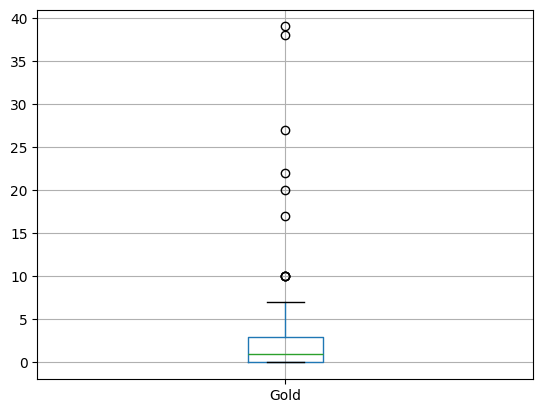

In [37]:
df_medal.boxplot(column="Gold",by=None,ax=None)

In [38]:
frequency_table = df_medal.copy()
frequency_table['freq']=pd.cut(df_medal["Gold"],10)
frequency_table.groupby("freq")["Rank"].count().reset_index()

/var/folders/g4/lb3fw8gj0rv183gv0r4pp_tr0000gn/T/ipykernel_6316/4142262736.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequency_table.groupby("freq")["Rank"].count().reset_index()


,freq,Rank
0,"(-0.039, 3.9]",72
1,"(3.9, 7.8]",11
2,"(7.8, 11.7]",4
3,"(11.7, 15.6]",0
4,"(15.6, 19.5]",1
5,"(19.5, 23.4]",2
6,"(23.4, 27.3]",1
7,"(27.3, 31.2]",0
8,"(31.2, 35.1]",0
9,"(35.1, 39.0]",2


In [39]:
#Histogram

np.histogram(df_medal["Gold"],bins=10)

(array([72, 11,  4,  0,  1,  2,  1,  0,  0,  2]),
 array([ 0. ,  3.9,  7.8, 11.7, 15.6, 19.5, 23.4, 27.3, 31.2, 35.1, 39. ]))

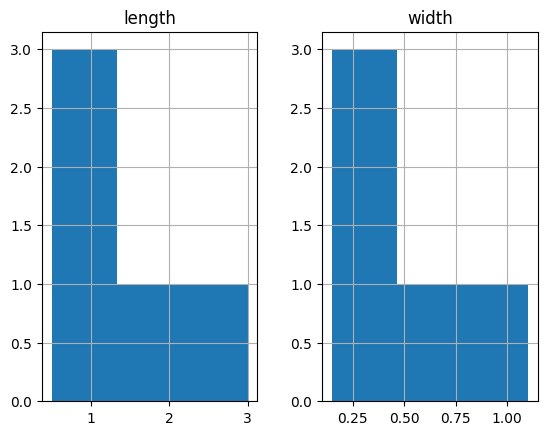

In [40]:
import matplotlib.pyplot
data = {'length': [1.5, 0.5, 1.2, 0.9, 3],
         'width': [0.7, 0.2, 0.15, 0.2, 1.1]}
index = ['pig', 'rabbit', 'duck', 'chicken', 'horse']
df = pd.DataFrame(data, index=index)
hist = df.hist(bins=3)

(array([50., 11., 11.,  5.,  2.,  4.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  1.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  2.]),
 array([ 0. ,  1.3,  2.6,  3.9,  5.2,  6.5,  7.8,  9.1, 10.4, 11.7, 13. ,
        14.3, 15.6, 16.9, 18.2, 19.5, 20.8, 22.1, 23.4, 24.7, 26. , 27.3,
        28.6, 29.9, 31.2, 32.5, 33.8, 35.1, 36.4, 37.7, 39. ]),
 <BarContainer object of 30 artists>)

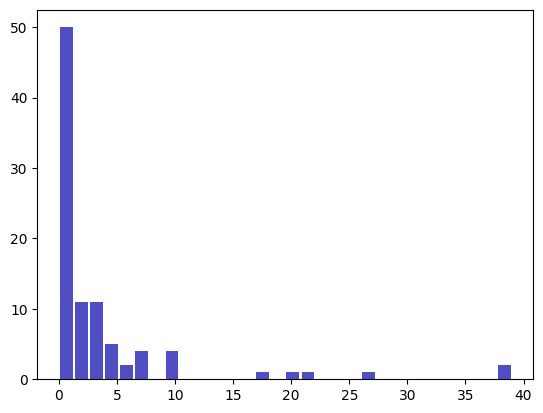

In [41]:
plt.hist(x=df_medal["Gold"],bins='auto',color='#0504aa',alpha=0.7,rwidth=0.85)

In [42]:
#First moment :Mean
#Second moment is central tendency
#third moment is Skeweness
#Fourthmoment is kurtosis

/var/folders/g4/lb3fw8gj0rv183gv0r4pp_tr0000gn/T/ipykernel_6316/2496773750.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_medal["Gold"], shade=True, color='blue', linewidth=2)


Text(0, 0.5, 'Density')

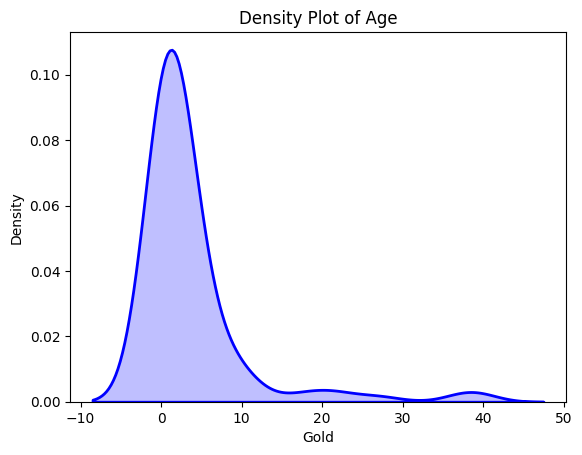

In [43]:
#density table 
import seaborn as sns
# Create a density plot for the 'Age' column
sns.kdeplot(df_medal["Gold"], shade=True, color='blue', linewidth=2)

# Customize the plot
plt.title('Density Plot of Age')
plt.xlabel('Gold')
plt.ylabel('Density')


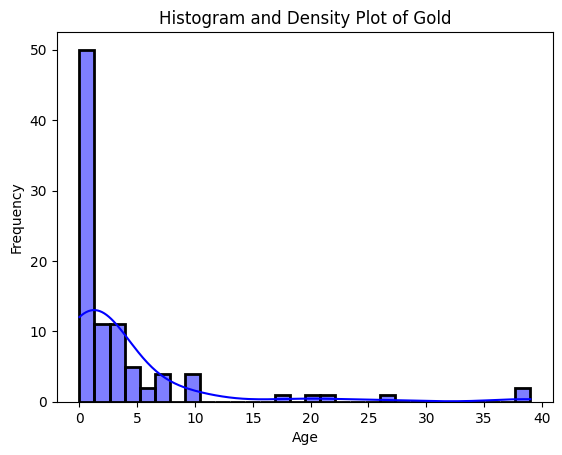

In [44]:
# Create a histogram with a density plot for the 'Age' column
sns.histplot(df_medal["Gold"], kde=True, color='blue', bins=30, linewidth=2)

# Customize the plot
plt.title('Histogram and Density Plot of Gold')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [45]:
#EXLORING Binary and Catagorical Data

In [46]:
df_medal["Gold"].mode()

0    0
Name: Gold, dtype: int64

In [47]:
#Bar chart

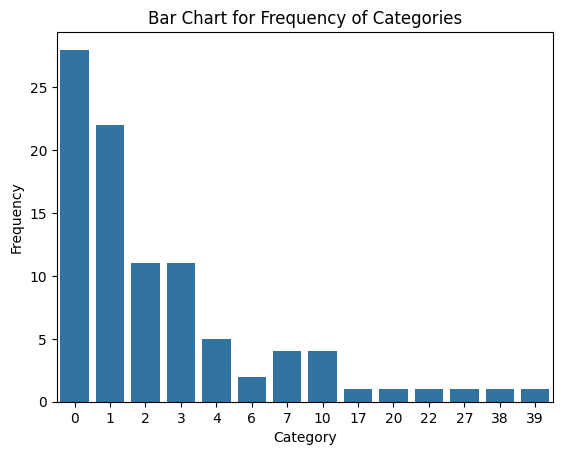

In [48]:
# Create a bar chart for frequency of 'Category'
sns.countplot(x='Gold', data=df_medal)

# Customize the plot
plt.title('Bar Chart for Frequency of Categories')
plt.xlabel('Category')
plt.ylabel('Frequency')

# Show the plot
plt.show()

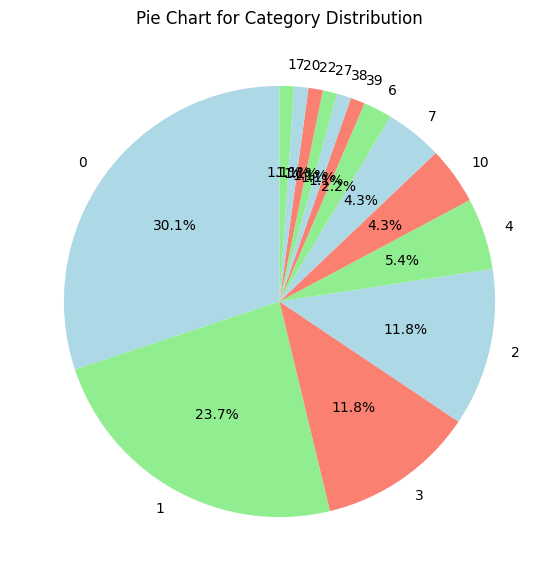

In [49]:
category_counts = df_medal['Gold'].value_counts()

# Create a pie chart
plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'salmon'])

# Customize the plot
plt.title('Pie Chart for Category Distribution')

# Show the plot
plt.show()

In [50]:
df_numeric = df_medal.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()

In [51]:
correlation_matrix

,Rank,Gold,Silver,Bronze,Total,Rank by Total
Rank,1.000000,-0.655477,-0.597835,-0.637166,-0.655877,0.873539
Gold,-0.655477,1.000000,0.929046,0.862425,0.970840,-0.626012
Silver,-0.597835,0.929046,1.000000,0.862646,0.969439,-0.632831
Bronze,-0.637166,0.862425,0.862646,1.000000,0.941941,-0.745573
Total,-0.655877,0.970840,0.969439,0.941941,1.000000,-0.692450
Rank by Total,0.873539,-0.626012,-0.632831,-0.745573,-0.692450,1.000000


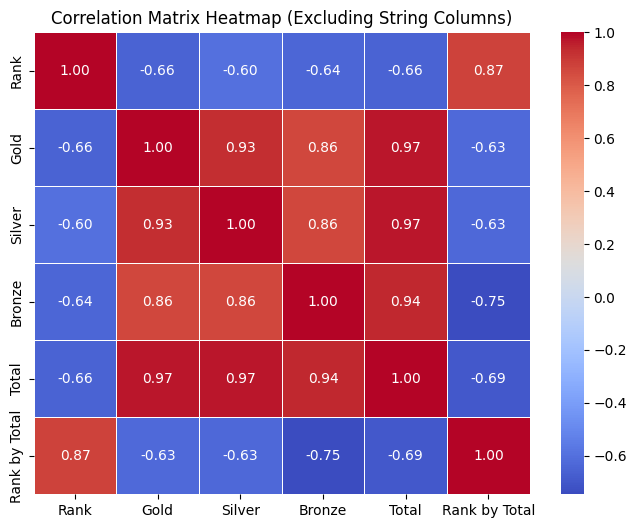

In [52]:
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Customize the plot
plt.title('Correlation Matrix Heatmap (Excluding String Columns)')

# Show the plot
plt.show()

In [53]:
##covariance
#df_medal.cov()
df_numeric = df_medal.select_dtypes(include=[np.number])

# Calculate the covariance matrix for the numeric columns only
cov_matrix = df_numeric.cov()

In [54]:
cov_matrix

,Rank,Gold,Silver,Bronze,Total,Rank by Total
Rank,687.442029,-120.688406,-103.865942,-103.750000,-328.304348,553.615942
Gold,-120.688406,49.315101,43.231533,37.612202,130.158836,-106.262740
Silver,-103.865942,43.231533,43.908368,35.499649,122.639551,-101.360683
Bronze,-103.750000,37.612202,35.499649,38.568724,111.680575,-111.922160
Total,-328.304348,130.158836,122.639551,111.680575,364.478962,-319.545582
Rank by Total,553.615942,-106.262740,-101.360683,-111.922160,-319.545582,584.274427


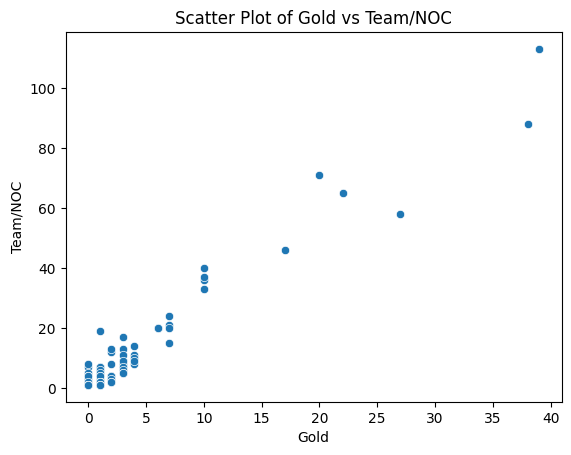

In [55]:
##Scattering plot
# Create a scatter plot of 'Age' vs 'Income'
sns.scatterplot(x='Gold', y='Total', data=df_medal)

# Customize the plot
plt.title('Scatter Plot of Gold vs Team/NOC')
plt.xlabel('Gold')
plt.ylabel('Team/NOC')

# Show the plot
plt.show()

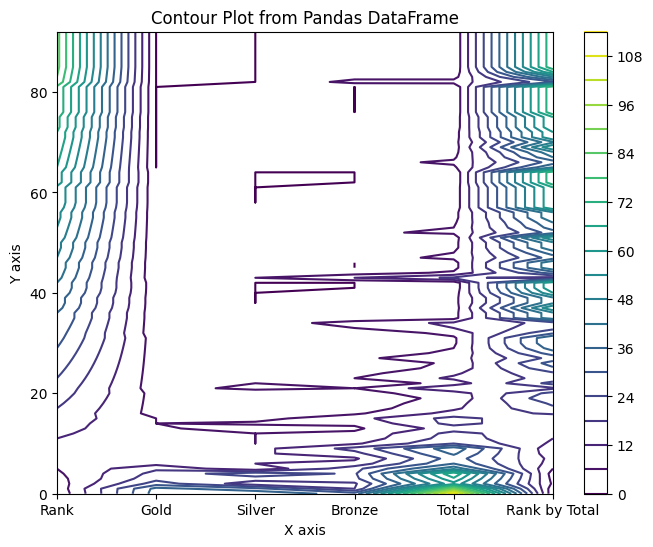

In [56]:
#contour plot
df_numeric = df_medal.select_dtypes(include=[np.number])
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)
df_numeric = df_numeric.fillna(0)
plt.figure(figsize=(8, 6))
cp = plt.contour(df_numeric.columns, df_numeric.index, df_numeric.values, 20, cmap='viridis')  # 20 contour levels

# Add a colorbar to the plot
plt.colorbar(cp)

# Set titles and labels
plt.title('Contour Plot from Pandas DataFrame')
plt.xlabel('X axis')
plt.ylabel('Y axis')

# Show the plot
plt.show()

In [57]:
# Create the contingency table
contingency_table = pd.crosstab(df_medal['Gold'], df_medal['Total'])

# Display the contingency table
print("\nContingency Table:")
print(contingency_table)



Contingency Table:
Total  1    2    3    4    5    6    7    8    9    10   ...  33   36   37   \
Gold                                                     ...                  
0       14    4    3    3    2    0    1    1    0    0  ...    0    0    0   
1        3    5    1    6    1    2    3    0    0    0  ...    0    0    0   
2        0    2    2    4    0    0    0    1    0    0  ...    0    0    0   
3        0    0    0    0    2    1    2    1    2    0  ...    0    0    0   
4        0    0    0    0    0    0    0    1    1    1  ...    0    0    0   
6        0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
7        0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
10       0    0    0    0    0    0    0    0    0    0  ...    1    1    1   
17       0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
20       0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
22       0    0    0    0    0  

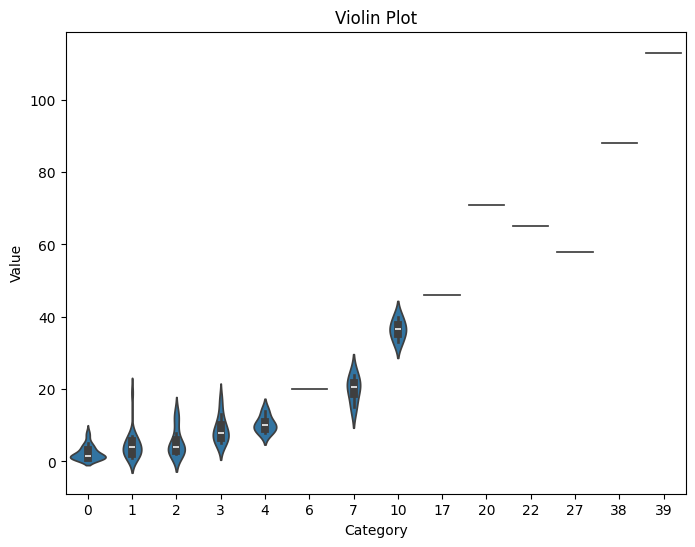

In [58]:
# Create a violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='Gold', y='Total', data=df_medal)

# Add a title and labels
plt.title('Violin Plot')
plt.xlabel('Category')
plt.ylabel('Value')

# Show the plot
plt.show()

<Axes: xlabel='Gold'>

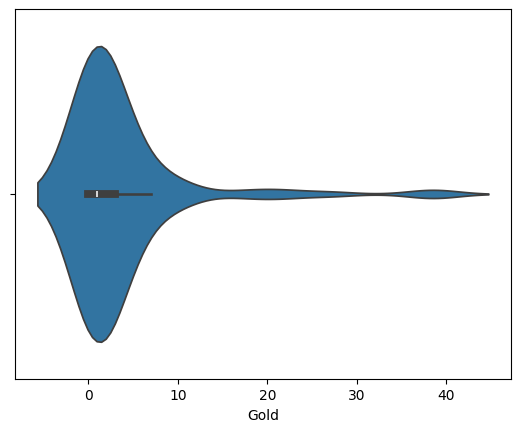

In [60]:
sns.violinplot(x=df_medal['Gold'])
